In [30]:
import pandas as pd
import numpy as np

# Load raw data
df = pd.read_csv('../data/raw/genz_alpha_interests_raw.csv')

# First look
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

Shape: (20, 13)

Columns: ['domain', 'cohort', 'trend_cycle_months', 'platform_dependency', 'identity_attachment', 'identity_type', 'attention_shift_rate', 'peer_influence_score', 'source_1', 'source_1_url', 'source_2', 'source_2_url', 'reasoning']


In [31]:
# Check for missing values
print("=== Missing values ===")
print(df.isnull().sum())

# Check data types
print("\n=== Data types ===")
print(df.dtypes)

# Check for duplicates
print("\n=== Duplicate rows ===")
print(df.duplicated().sum())

=== Missing values ===
domain                  0
cohort                  0
trend_cycle_months      0
platform_dependency     0
identity_attachment     0
identity_type           0
attention_shift_rate    0
peer_influence_score    0
source_1                0
source_1_url            0
source_2                0
source_2_url            0
reasoning               0
dtype: int64

=== Data types ===
domain                   object
cohort                   object
trend_cycle_months      float64
platform_dependency     float64
identity_attachment     float64
identity_type            object
attention_shift_rate    float64
peer_influence_score    float64
source_1                 object
source_1_url             object
source_2                 object
source_2_url             object
reasoning                object
dtype: object

=== Duplicate rows ===
0


In [32]:
# Check what values identity_type actually contains
print("=== identity_type unique values ===")
print(df['identity_type'].unique())

print("\n=== identity_type counts ===")
print(df['identity_type'].value_counts())

# Check numeric columns are in expected ranges
print("\n=== Numeric ranges ===")
numeric_cols = ['trend_cycle_months', 'platform_dependency', 
                'identity_attachment', 'attention_shift_rate', 
                'peer_influence_score']
print(df[numeric_cols].describe().round(2))

=== identity_type unique values ===
['achieved' 'aspirational']

=== identity_type counts ===
identity_type
aspirational    13
achieved         7
Name: count, dtype: int64

=== Numeric ranges ===
       trend_cycle_months  platform_dependency  identity_attachment  \
count               20.00                20.00                20.00   
mean                 9.07                 5.62                 7.00   
std                  9.04                 1.60                 1.38   
min                  1.00                 3.00                 4.50   
25%                  2.42                 4.50                 6.00   
50%                  5.75                 5.50                 7.10   
75%                 14.00                 7.00                 8.05   
max                 32.00                 8.50                 9.20   

       attention_shift_rate  peer_influence_score  
count                 20.00                 20.00  
mean                   6.53                  7.12  
std     

## Step 3 — Data Cleaning

**Dataset:** `genz_alpha_interests_raw.csv`  
**Shape:** 20 rows × 13 columns  
**Cohorts:** Gen Z (10 rows), Gen Alpha (10 rows)  

### Checks performed:
| Check | Result |
|---|---|
| Missing values | 0 across all 13 columns |
| Duplicate rows | 0 |
| Data types | All numeric cols float64, categoricals object |
| identity_type values | Exactly 2 — 'achieved' and 'aspirational' |
| Numeric ranges | All within expected bounds |

### Cleaning actions taken:
None required — dataset was construction-clean.

### Note:
Dataset is synthetic, built from literature estimates. 
Values were reasoned from real sources during construction, 
not collected from raw messy data. This is standard practice 
in domains where no public dataset exists.

In [33]:
# Q1 — Which domains have shortest trend cycle for Gen Z?
# Shorter cycle = changes faster = higher volatility

genz = df[df['cohort'] == 'Gen Z'].copy()

# Sort all 10 domains by trend cycle shortest to longest
genz_cycle = genz[['domain', 'trend_cycle_months']].sort_values('trend_cycle_months')

print("=== Gen Z — Trend cycle length per domain (months) ===")
print("Shortest = changes fastest, Longest = most stable")
print()
print(genz_cycle.to_string(index=False))

=== Gen Z — Trend cycle length per domain (months) ===
Shortest = changes fastest, Longest = most stable

             domain  trend_cycle_months
              Music                 1.2
       Social Media                 2.2
            Fashion                 2.5
       Food & Drink                 3.5
   Sports & Fitness                 5.5
Activism & Politics                 6.5
             Gaming                 8.0
            Finance                14.0
      Mental Health                18.0
 Career & Education                26.0


### Q1 Finding — Gen Z trend cycles reveal 3 natural clusters

Three distinct tiers emerge, mapping directly to the 
3 volatility drivers identified in dataset design:

| Cluster | Domains | Avg cycle | Driver |
|---|---|---|---|
| Fast | Music, Social Media, Fashion | 1.2–2.5 months | Environment |
| Mid | Food, Sports, Activism, Gaming | 3.5–8.0 months | Conditions |
| Slow | Finance, Mental Health, Career | 14–26 months | Self/Identity |

**Key insight:** The slowest domains are identity-rooted — 
people don't abandon who they are. The fastest domains 
are environment-driven — external world changes pull 
them along.

In [34]:
# Q2 — Which domains need most product provider attention for Gen Z?
# High peer influence + high attention shift rate = domain is active and socially driven
# These are the domains where staying visible matters most

genz = df[df['cohort'] == 'Gen Z'].copy()

# Combine peer influence and attention shift rate
# Simple average of both — equal weight for now
genz['provider_priority'] = (genz['peer_influence_score'] + genz['attention_shift_rate']) / 2

# Sort all 10 domains highest to lowest
genz_priority = genz[['domain', 'peer_influence_score', 
                       'attention_shift_rate', 
                       'provider_priority']].sort_values('provider_priority', ascending=False)

print("=== Gen Z — Product provider priority per domain ===")
print("Higher score = domain needs more active attention")
print()
print(genz_priority.to_string(index=False))

=== Gen Z — Product provider priority per domain ===
Higher score = domain needs more active attention

             domain  peer_influence_score  attention_shift_rate  provider_priority
   Sports & Fitness                   7.8                   9.0               8.40
      Mental Health                   5.5                  11.0               8.25
            Finance                   6.5                   8.5               7.50
       Social Media                   8.2                   6.7               7.45
Activism & Politics                   8.5                   6.0               7.25
 Career & Education                   6.8                   7.5               7.15
            Fashion                   8.5                   5.5               7.00
       Food & Drink                   7.5                   5.5               6.50
             Gaming                   7.5                   3.5               5.50
              Music                   6.5                   2.0   

### Q2 Finding — Highest priority domains for Gen Z 
### product providers are not the obvious ones

Expected: Social Media and Fashion at top
Actual: Sports & Fitness, Mental Health, Finance lead

| Domain | Why it ranks high |
|---|---|
| Sports & Fitness | Fastest growing attention (9.0) + strong peer culture |
| Mental Health | Explosive attention growth (11.0) — people actively seeking |
| Finance | Rapidly growing (8.5) — Gen Z entering financial adulthood |

**Key insight:** Social Media and Fashion feel dominant 
because they are loud. But loudness ≠ growth opportunity. 
The domains growing fastest in attention are where 
product providers have the most room to enter.

In [35]:
# Q3 — Which domains have shortest trend cycle for Gen Alpha?

alpha = df[df['cohort'] == 'Gen Alpha'].copy()

# Sort all 10 domains by trend cycle shortest to longest
alpha_cycle = alpha[['domain', 'trend_cycle_months']].sort_values('trend_cycle_months')

print("=== Gen Alpha — Trend cycle length per domain (months) ===")
print("Shortest = changes fastest, Longest = most stable")
print()
print(alpha_cycle.to_string(index=False))

# Also compare directly with Gen Z side by side
print("\n=== Side by side comparison — Gen Z vs Gen Alpha ===")
genz = df[df['cohort'] == 'Gen Z'][['domain','trend_cycle_months']].rename(
    columns={'trend_cycle_months': 'genz_cycle'})
alpha2 = df[df['cohort'] == 'Gen Alpha'][['domain','trend_cycle_months']].rename(
    columns={'trend_cycle_months': 'alpha_cycle'})

compare = genz.merge(alpha2, on='domain')
compare['alpha_faster_by'] = (compare['genz_cycle'] - compare['alpha_cycle']).round(1)
compare = compare.sort_values('alpha_cycle')

print(compare.to_string(index=False))

=== Gen Alpha — Trend cycle length per domain (months) ===
Shortest = changes fastest, Longest = most stable

             domain  trend_cycle_months
              Music                 1.0
       Social Media                 1.8
            Fashion                 1.8
       Food & Drink                 2.8
   Sports & Fitness                 4.5
             Gaming                 6.0
Activism & Politics                 8.0
      Mental Health                14.0
            Finance                22.0
 Career & Education                32.0

=== Side by side comparison — Gen Z vs Gen Alpha ===
             domain  genz_cycle  alpha_cycle  alpha_faster_by
              Music         1.2          1.0              0.2
       Social Media         2.2          1.8              0.4
            Fashion         2.5          1.8              0.7
       Food & Drink         3.5          2.8              0.7
   Sports & Fitness         5.5          4.5              1.0
             Gaming     

### Q3 Finding — Gen Alpha is faster than Gen Z 
### in most domains, but slower in 3 specific ones

**Pattern 1 — Alpha faster in environment-driven domains:**
Music, Social Media, Fashion, Food, Sports — 
Alpha cycles faster because aspirational identity 
shifts more easily than achieved identity.

**Pattern 2 — Alpha slower in self-driven domains:**

| Domain | Gen Z cycle | Alpha cycle | Gap | Why |
|---|---|---|---|---|
| Finance | 14 months | 22 months | -8.0 | Abstract for Alpha, urgent for Gen Z |
| Career | 26 months | 32 months | -6.0 | Alpha not in career phase yet |
| Activism | 6.5 months | 8.0 months | -1.5 | Alpha sustained, Gen Z fatigued |

**Methodological note:**
Gen Alpha data carries maturity bias — they are still 
in early life stages. Their patterns are based on early 
signals not fully lived behaviour. Finance and Career 
predictions especially should be treated as directional 
estimates, not definitive measurements.

In [36]:
# Q4 — Which domains need most product provider attention for Gen Alpha?

alpha = df[df['cohort'] == 'Gen Alpha'].copy()

# Same formula as Q2 — peer influence + attention shift rate
alpha['provider_priority'] = (alpha['peer_influence_score'] + alpha['attention_shift_rate']) / 2

alpha_priority = alpha[['domain', 'peer_influence_score',
                         'attention_shift_rate',
                         'provider_priority']].sort_values('provider_priority', ascending=False)

print("=== Gen Alpha — Product provider priority per domain ===")
print("Higher score = domain needs more active attention")
print()
print(alpha_priority.to_string(index=False))

# Compare Gen Z vs Alpha priority side by side
print("\n=== Priority comparison — Gen Z vs Gen Alpha ===")
genz = df[df['cohort'] == 'Gen Z'].copy()
genz['provider_priority'] = (genz['peer_influence_score'] + genz['attention_shift_rate']) / 2

alpha2 = alpha[['domain','provider_priority']].rename(
    columns={'provider_priority':'alpha_priority'})
genz2 = genz[['domain','provider_priority']].rename(
    columns={'provider_priority':'genz_priority'})

compare = genz2.merge(alpha2, on='domain')
compare['priority_shift'] = (compare['alpha_priority'] - compare['genz_priority']).round(2)
compare = compare.sort_values('alpha_priority', ascending=False)

print(compare.to_string(index=False))

=== Gen Alpha — Product provider priority per domain ===
Higher score = domain needs more active attention

             domain  peer_influence_score  attention_shift_rate  provider_priority
      Mental Health                   6.0                  13.0               9.50
Activism & Politics                   9.0                   9.0               9.00
       Social Media                   9.4                   8.5               8.95
   Sports & Fitness                   7.5                   7.5               7.50
            Fashion                   8.0                   7.0               7.50
       Food & Drink                   7.8                   6.5               7.15
             Gaming                   8.0                   4.0               6.00
 Career & Education                   5.0                   4.0               4.50
            Finance                   4.0                   3.5               3.75
              Music                   4.5                   2.

### Q4 Finding — Mental Health and Activism are 
### highest priority domains for Gen Alpha providers

**Top 3 Alpha priority domains:**
| Domain | Priority Score | Why |
|---|---|---|
| Mental Health | 9.50 | Fastest growing attention (13.0) of all domains |
| Activism & Politics | 9.00 | High peer drive + rapid attention growth |
| Social Media | 8.95 | Platform-native, peer-saturated |

**Biggest shifts from Gen Z → Gen Alpha:**
| Domain | Shift | Strategic meaning |
|---|---|---|
| Activism & Politics | +1.75 | Shift budget toward Alpha here |
| Social Media | +1.50 | Alpha more platform-native |
| Mental Health | +1.25 | Universal priority, higher for Alpha |
| Finance | -3.75 | Gen Z domain — don't over-invest for Alpha |
| Career & Education | -2.65 | Not relevant for Alpha yet |

**Cross-cohort finding:**
Mental Health is the only domain ranking in top 2 
for BOTH cohorts. It is the single most universal 
domain across generations.

**Budget allocation insight:**
For Activism & Politics with equal budget across cohorts,
~55% should target Gen Alpha, ~45% Gen Z based on 
relative priority scores.

In [37]:
# ── STEP 6 — SCORING ENGINE ───────────────────────────────────────

# Step A — Normalise all columns to 0–1
# Formula: (value - min) / (max - min)
# Result: lowest value becomes 0, highest becomes 1

def normalise(series):
    return (series - series.min()) / (series.max() - series.min())

d = df.copy()

# trend_cycle: SHORT cycle = MORE volatile
# so we INVERT after normalising — 1 minus normalised
# this way Music (1.0 months) gets score 1.0 (most volatile)
# and Career (32.0 months) gets score 0.0 (least volatile)
d['trend_inv']      = 1 - normalise(d['trend_cycle_months'])
d['platform_norm']  = normalise(d['platform_dependency'])
d['attention_norm'] = normalise(d['attention_shift_rate'])
d['peer_norm']      = normalise(d['peer_influence_score'])
d['identity_norm']  = normalise(d['identity_attachment'])

# Step B — Apply weights
d['raw_score'] = (
    0.35 * d['trend_inv'] +
    0.25 * d['peer_norm'] +
    0.20 * d['attention_norm'] +
    0.20 * d['platform_norm']
)

# Step C — Hard constraint
# High identity attachment caps volatility at 0.65
IDENTITY_THRESHOLD = 7.0
IDENTITY_CAP       = 0.65

d['volatility_score'] = d.apply(
    lambda row: min(row['raw_score'], IDENTITY_CAP)
    if row['identity_attachment'] > IDENTITY_THRESHOLD
    else row['raw_score'],
    axis=1
)

# Step D — Assign tier
def assign_tier(score):
    if score >= 0.75:   return '🔴 Quicksand'
    elif score >= 0.55: return '🟠 Shifting'
    elif score >= 0.35: return '🟡 Stable'
    else:               return '🟢 Evergreen'

d['tier'] = d['volatility_score'].apply(assign_tier)

# Show results
result = d[['domain','cohort','identity_attachment',
            'raw_score','volatility_score','tier']].copy()
result['raw_score']       = result['raw_score'].round(3)
result['volatility_score'] = result['volatility_score'].round(3)

print("=== Volatility scores — all 10 domains × 2 cohorts ===")
print()
print(result.sort_values(['cohort','volatility_score'], 
      ascending=[True,False]).to_string(index=False))

=== Volatility scores — all 10 domains × 2 cohorts ===

             domain    cohort  identity_attachment  raw_score  volatility_score        tier
            Fashion Gen Alpha                  5.5      0.770             0.770 🔴 Quicksand
   Sports & Fitness Gen Alpha                  6.5      0.736             0.736  🟠 Shifting
       Food & Drink Gen Alpha                  7.0      0.733             0.733  🟠 Shifting
       Social Media Gen Alpha                  7.2      0.775             0.650  🟠 Shifting
Activism & Politics Gen Alpha                  8.2      0.830             0.650  🟠 Shifting
             Gaming Gen Alpha                  8.0      0.606             0.606  🟠 Shifting
      Mental Health Gen Alpha                  8.5      0.550             0.550  🟠 Shifting
              Music Gen Alpha                  4.5      0.419             0.419    🟡 Stable
            Finance Gen Alpha                  4.5      0.158             0.158 🟢 Evergreen
 Career & Education Gen 

### Scoring Engine Finding

**Fashion Gen Alpha is the only Quicksand domain.**
Low identity attachment (5.5) + fast trend cycle + 
high peer influence + Shein/Temu removing cost barrier 
= no protection against volatility.

**Gen Z has zero Quicksand domains.**
Gen Z is in prime-to-post-prime transition. 
Most domain decisions are made — they evolve 
within domains but don't abandon them.

**Gen Alpha has more extremes than Gen Z:**
- More Quicksand → forming identity, no anchor yet
- More Evergreen → Finance/Career not yet relevant,
  so attention barely moves

**Core insight:**
Volatility is not just about how fast trends move.
It is about whether a generation has made its 
decisions yet. Gen Z has. Gen Alpha hasn't.

**Why Gen Z has zero Evergreen domains:**
Gen Z has started everything but finished nothing.
They are mid-journey in every domain simultaneously —
old enough to engage, young enough to still be shifting.
They are the transition generation.

In [38]:
# Clean tier summary for reference
print("=== Final tier summary ===")
print()
for cohort in ['Gen Z', 'Gen Alpha']:
    print(f"── {cohort} ──")
    subset = d[d['cohort'] == cohort][['domain','volatility_score','tier']]
    subset = subset.sort_values('volatility_score', ascending=False)
    print(subset.to_string(index=False))
    print()

=== Final tier summary ===

── Gen Z ──
             domain  volatility_score       tier
            Fashion          0.732307 🟠 Shifting
       Social Media          0.707260 🟠 Shifting
       Food & Drink          0.674720 🟠 Shifting
   Sports & Fitness          0.650000 🟠 Shifting
Activism & Politics          0.650000 🟠 Shifting
             Gaming          0.569368 🟠 Shifting
              Music          0.518028   🟡 Stable
            Finance          0.509876   🟡 Stable
      Mental Health          0.409327   🟡 Stable
 Career & Education          0.351917   🟡 Stable

── Gen Alpha ──
             domain  volatility_score        tier
            Fashion          0.769789 🔴 Quicksand
   Sports & Fitness          0.736157  🟠 Shifting
       Food & Drink          0.732876  🟠 Shifting
       Social Media          0.650000  🟠 Shifting
Activism & Politics          0.650000  🟠 Shifting
             Gaming          0.606006  🟠 Shifting
      Mental Health          0.550364  🟠 Shifting
    

In [39]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Colour palette — consistent across all charts
GENZ_COLOR  = '#7F77DD'   # purple
ALPHA_COLOR = '#1D9E75'   # teal  
ACCENT      = '#D85A30'   # coral

# Chart style — consistent across all charts
plt.rcParams.update({
    'font.family'       : 'DejaVu Sans',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.grid'         : True,
    'grid.alpha'        : 0.3,
    'grid.linestyle'    : '--',
    'figure.dpi'        : 150,
    'savefig.dpi'       : 150,
    'savefig.bbox'      : 'tight',
    'savefig.facecolor' : 'white'
})

# Make sure outputs folder exists
import os
os.makedirs('../outputs/charts', exist_ok=True)

print("Libraries loaded. Ready to chart.")

Libraries loaded. Ready to chart.


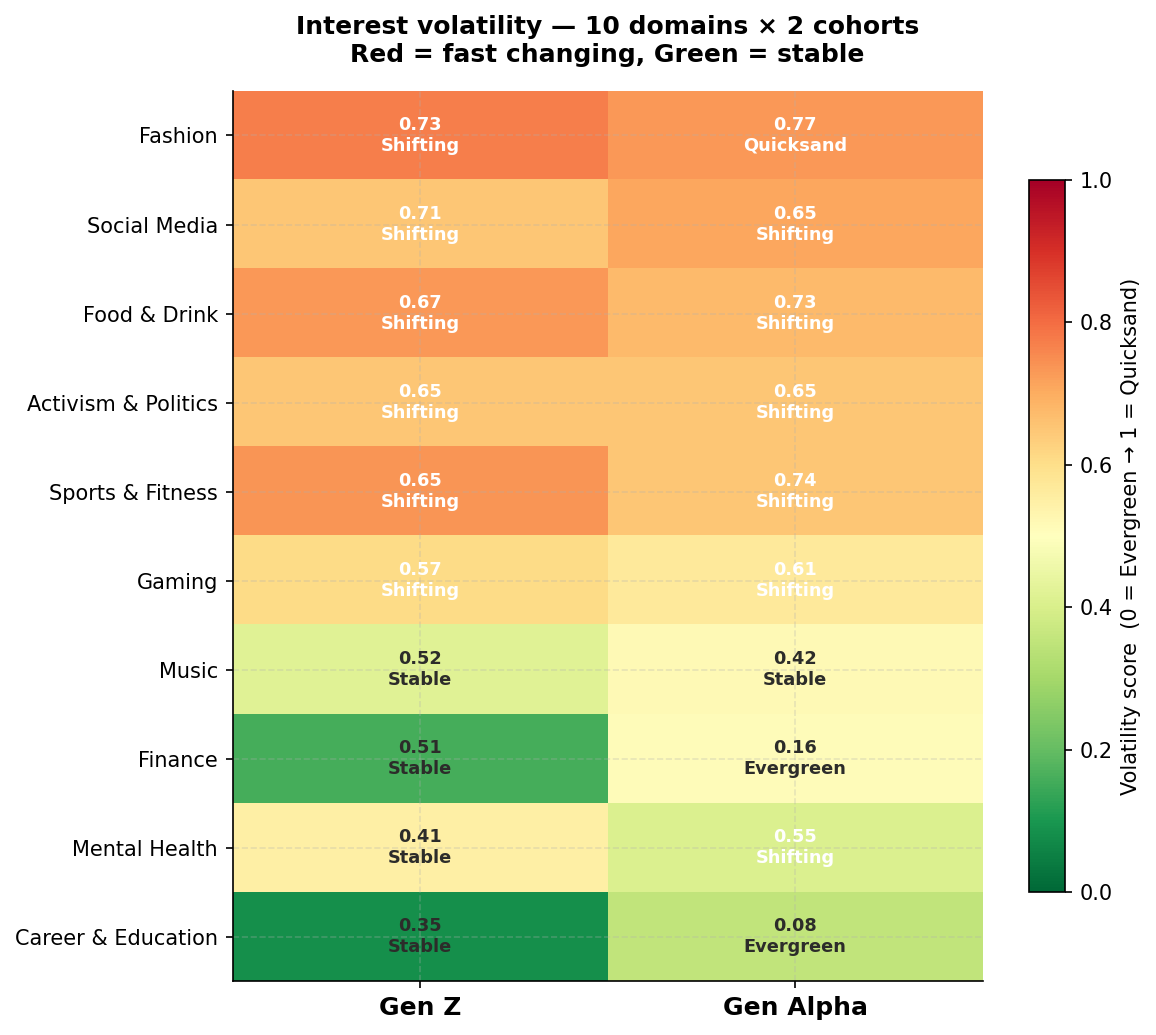

Chart 1 saved.


In [40]:
# ── CHART 1 — Volatility Heatmap ─────────────────────────────────
# One insight: Gen Alpha is more volatile than Gen Z in most domains

# Build pivot table — domains as rows, cohorts as columns
pivot = d.pivot(index='domain', columns='cohort', values='volatility_score')

# Sort by Gen Z score so most volatile domains are at top
pivot = pivot.sort_values('Gen Z', ascending=False)

# Tier labels for each cell
def get_tier_label(score):
    if score >= 0.75:   return 'Quicksand'
    elif score >= 0.55: return 'Shifting'
    elif score >= 0.35: return 'Stable'
    else:               return 'Evergreen'

fig, ax = plt.subplots(figsize=(8, 7))

# Draw heatmap using imshow
im = ax.imshow(pivot.values, 
               cmap=plt.cm.RdYlGn_r,  # red=volatile green=stable
               aspect='auto', 
               vmin=0, vmax=1)

# Axis labels
ax.set_xticks([0, 1])
ax.set_xticklabels(['Gen Z', 'Gen Alpha'], fontsize=12, fontweight='bold')
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=10)

# Add score + tier label inside each cell
for i in range(len(pivot.index)):
    for j, cohort in enumerate(['Gen Z', 'Gen Alpha']):
        val   = pivot.loc[pivot.index[i], cohort]
        label = get_tier_label(val)
        color = 'white' if val > 0.55 else '#2C2C2A'
        ax.text(j, i, f'{val:.2f}\n{label}',
                ha='center', va='center',
                fontsize=8.5, fontweight='bold', color=color)

# Colorbar
plt.colorbar(im, ax=ax, 
             label='Volatility score  (0 = Evergreen → 1 = Quicksand)', 
             shrink=0.8)

ax.set_title('Interest volatility — 10 domains × 2 cohorts\nRed = fast changing, Green = stable',
             fontsize=12, fontweight='bold', pad=14)

plt.tight_layout()
plt.savefig('../outputs/charts/chart1_heatmap.png')
plt.show()
print("Chart 1 saved.")

### Chart 1 Insight — Heatmap

**Gen Z spread: 0.35 → 0.73 (range 0.38)**
**Alpha spread: 0.08 → 0.77 (range 0.69)**

Alpha's spread is nearly double Gen Z's.

Gen Z is clustered in the middle — everything is 
active simultaneously. No domain is abandoned, 
none fully settled. Present tense opportunity —
products need consistent attention across all domains now.

Alpha shows clear separation — Fashion/Sports already 
volatile, Finance/Career completely untouched.
Future tense opportunity — acting early in Alpha's 
volatile domains before identity solidifies is the 
strategic window.

**One line summary:**
Sell to Gen Z today. Position for Gen Alpha tomorrow.

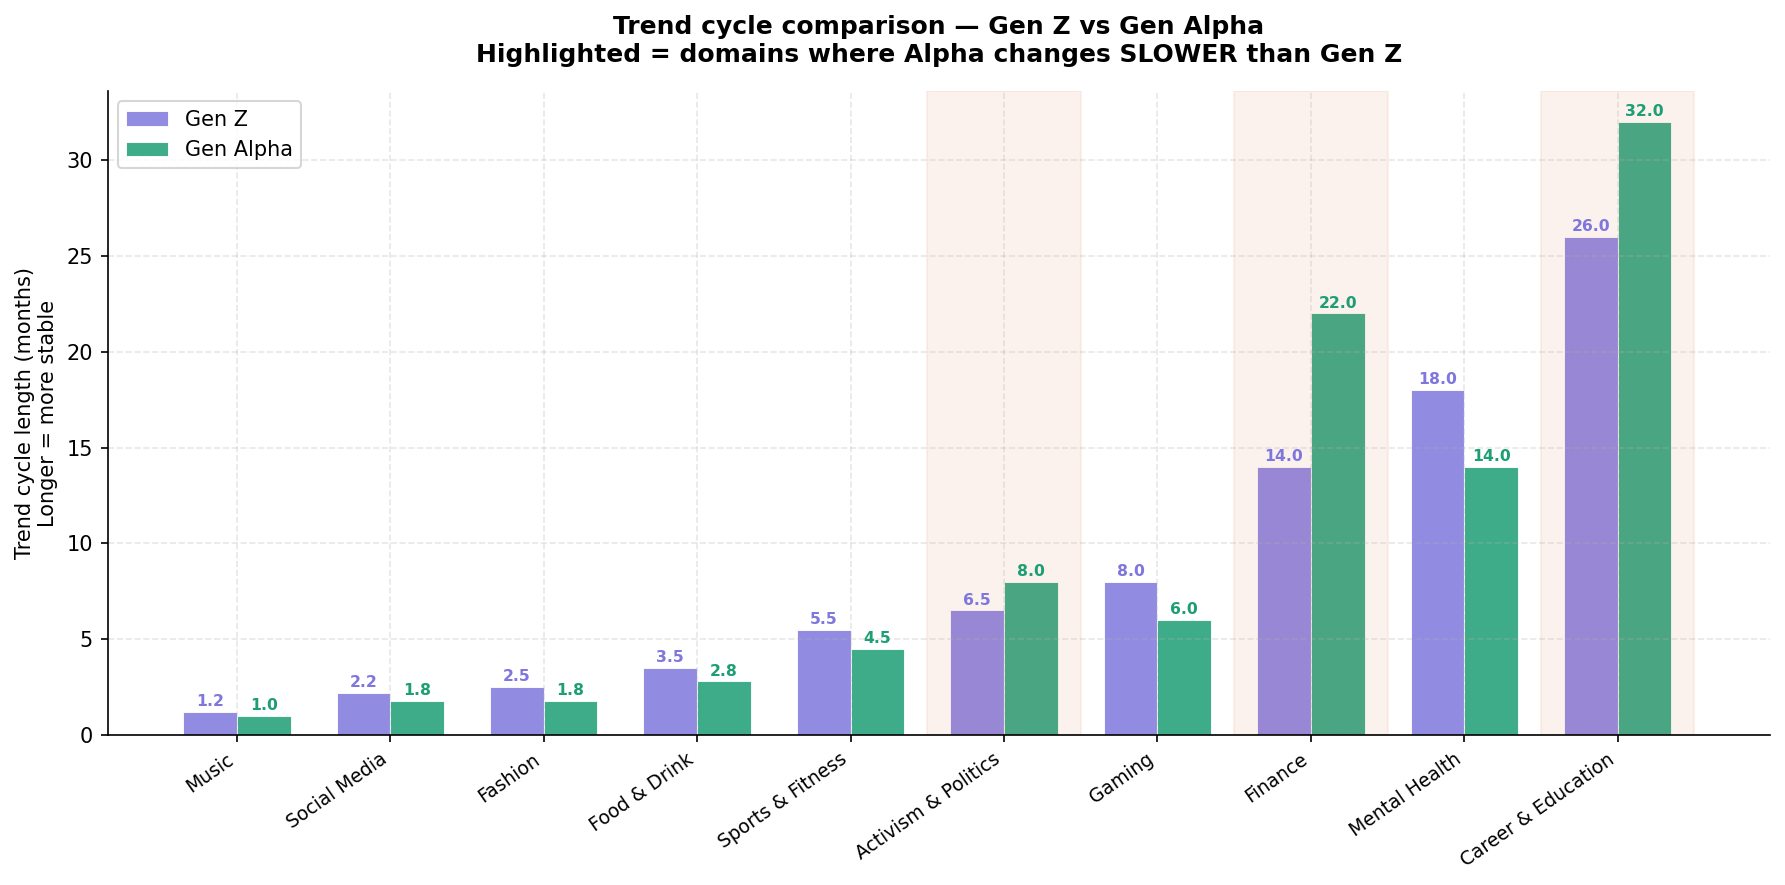

Chart 2 saved.


In [41]:
# ── CHART 2 — Trend Cycle Comparison ─────────────────────────────
# One insight: Alpha faster in environment domains, 
#              Gen Z faster in self-driven domains

genz_c  = d[d['cohort'] == 'Gen Z'][['domain','trend_cycle_months']].set_index('domain')
alpha_c = d[d['cohort'] == 'Gen Alpha'][['domain','trend_cycle_months']].set_index('domain')

# Sort by Gen Z cycle length
domains = genz_c.sort_values('trend_cycle_months').index.tolist()

genz_vals  = [genz_c.loc[dom, 'trend_cycle_months']  for dom in domains]
alpha_vals = [alpha_c.loc[dom, 'trend_cycle_months'] for dom in domains]

x = range(len(domains))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar([i - width/2 for i in x], genz_vals,
               width, label='Gen Z',
               color=GENZ_COLOR, alpha=0.85,
               edgecolor='white', linewidth=0.5)

bars2 = ax.bar([i + width/2 for i in x], alpha_vals,
               width, label='Gen Alpha',
               color=ALPHA_COLOR, alpha=0.85,
               edgecolor='white', linewidth=0.5)

# Add value labels on top of each bar
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{bar.get_height():.1f}',
            ha='center', fontsize=7.5, color=GENZ_COLOR, fontweight='bold')

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{bar.get_height():.1f}',
            ha='center', fontsize=7.5, color=ALPHA_COLOR, fontweight='bold')

# Highlight where Alpha is SLOWER than Gen Z
for i, dom in enumerate(domains):
    if alpha_c.loc[dom, 'trend_cycle_months'] > genz_c.loc[dom, 'trend_cycle_months']:
        ax.axvspan(i - 0.5, i + 0.5, alpha=0.08, color=ACCENT, label='_nolegend_')

ax.set_xticks(list(x))
ax.set_xticklabels(domains, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Trend cycle length (months)\nLonger = more stable', fontsize=10)
ax.set_title('Trend cycle comparison — Gen Z vs Gen Alpha\n'
             'Highlighted = domains where Alpha changes SLOWER than Gen Z',
             fontsize=12, fontweight='bold', pad=14)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/charts/chart2_trend_cycle.png')
plt.show()
print("Chart 2 saved.")

### Chart 2 Insight — Trend Cycle Comparison

Alpha is faster than Gen Z in 7 of 10 domains —
confirming aspirational identity shifts more easily
than achieved identity.

Three domains where Alpha is SLOWER than Gen Z:

| Domain | Gen Z | Alpha | Why |
|---|---|---|---|
| Finance | 14.0 | 22.0 | Abstract for Alpha, urgent for Gen Z |
| Career | 26.0 | 32.0 | Alpha not in career phase yet |
| Activism | 6.5 | 8.0 | Gen Z reactive+fatigued, Alpha sustained+conviction |

**Activism is the most interesting exception:**
Alpha is MORE activist in intensity but SLOWER in 
trend cycling. Gen Z activism burns fast and fatigues.
Alpha activism is conviction-driven — slower cycle, 
deeper commitment.

**Key insight:** Slower cycle does not mean less engaged.
For Activism, it means more genuinely committed.

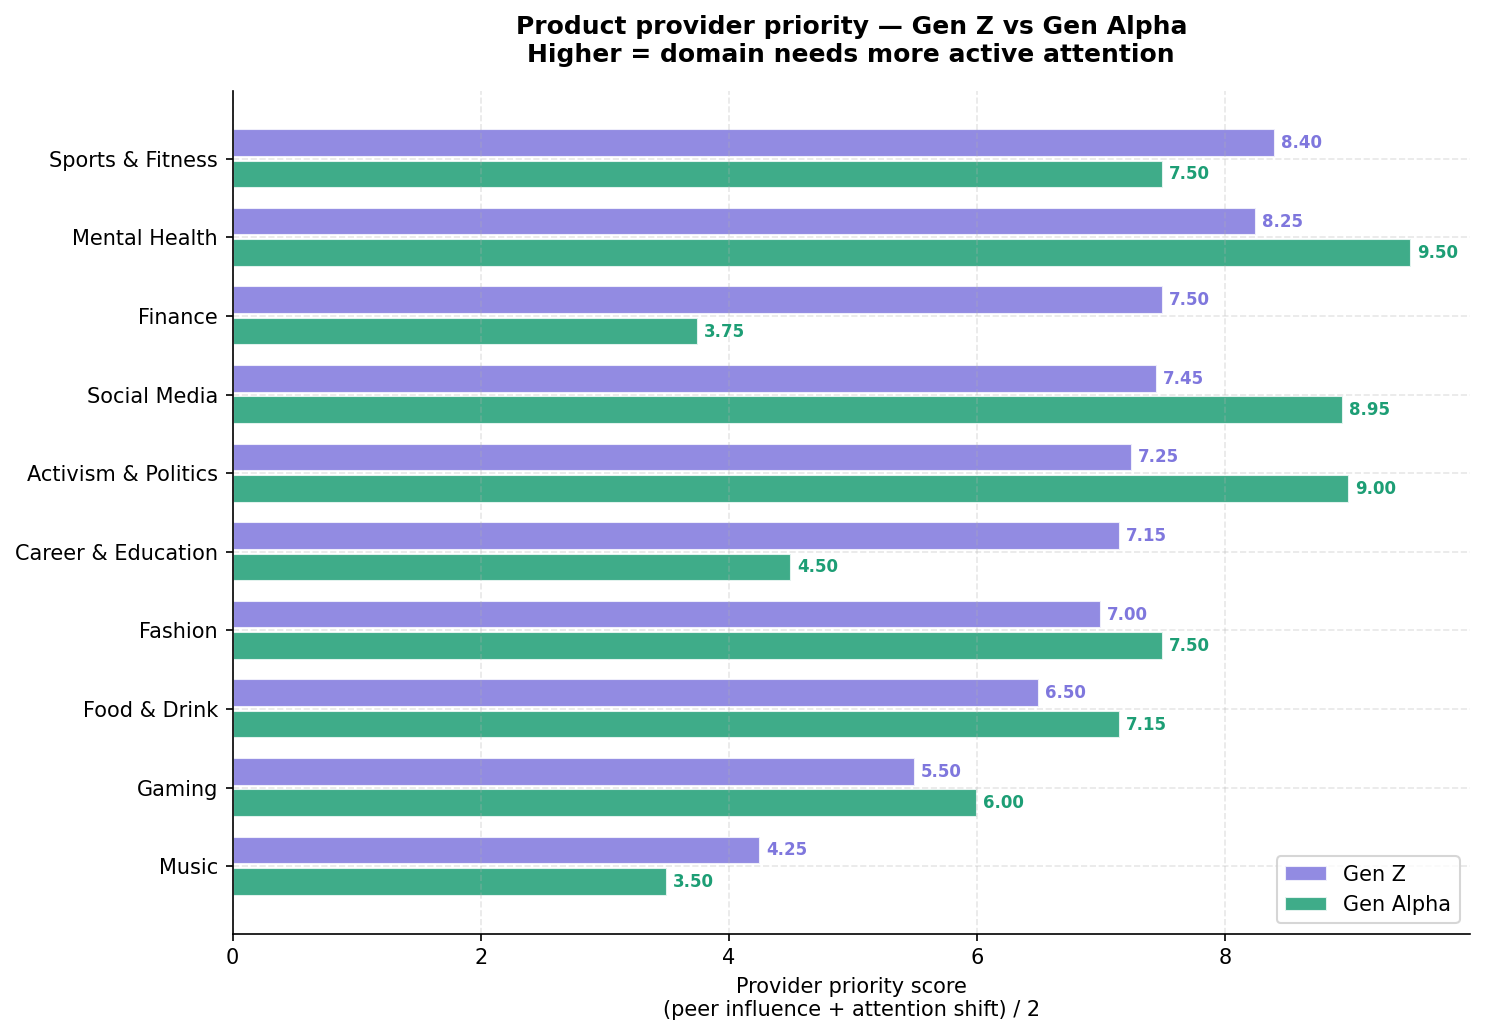

Chart 3 saved.


In [42]:
# ── CHART 3 — Provider Priority Comparison ───────────────────────
# One insight: Mental Health is top priority for BOTH cohorts

genz_p  = d[d['cohort'] == 'Gen Z'].copy()
alpha_p = d[d['cohort'] == 'Gen Alpha'].copy()

genz_p['priority']  = (genz_p['peer_influence_score']  + genz_p['attention_shift_rate'])  / 2
alpha_p['priority'] = (alpha_p['peer_influence_score'] + alpha_p['attention_shift_rate']) / 2

merged = genz_p[['domain','priority']].merge(
    alpha_p[['domain','priority']], on='domain', suffixes=('_genz','_alpha'))
merged = merged.sort_values('priority_genz', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
y = range(len(merged))
ax.barh([i + 0.2 for i in y], merged['priority_genz'],
        height=0.35, label='Gen Z',
        color=GENZ_COLOR, alpha=0.85, edgecolor='white')
ax.barh([i - 0.2 for i in y], merged['priority_alpha'],
        height=0.35, label='Gen Alpha',
        color=ALPHA_COLOR, alpha=0.85, edgecolor='white')

for i, row in enumerate(merged.itertuples()):
    ax.text(row.priority_genz  + 0.05, i + 0.2,
            f'{row.priority_genz:.2f}',  va='center', fontsize=8, color=GENZ_COLOR,  fontweight='bold')
    ax.text(row.priority_alpha + 0.05, i - 0.2,
            f'{row.priority_alpha:.2f}', va='center', fontsize=8, color=ALPHA_COLOR, fontweight='bold')

ax.set_yticks(list(y))
ax.set_yticklabels(merged['domain'], fontsize=10)
ax.set_xlabel('Provider priority score\n(peer influence + attention shift) / 2', fontsize=10)
ax.set_title('Product provider priority — Gen Z vs Gen Alpha\nHigher = domain needs more active attention',
             fontsize=12, fontweight='bold', pad=14)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('../outputs/charts/chart3_provider_priority.png')
plt.show()
print("Chart 3 saved.")

### Chart 3 Insight — Provider Priority

Mental Health is the only domain where Alpha (9.50) 
scores HIGHER than Gen Z (8.25) — and both are top 2.
Universal priority across both cohorts.

Three domains flip dramatically between cohorts:
- Finance: Gen Z 7.50 → Alpha 3.75 (halves)
- Career: Gen Z 7.15 → Alpha 4.50 (drops sharply)  
- Activism: Gen Z 7.25 → Alpha 9.00 (surges)

**One line:** Mental Health needs attention for everyone.
Activism needs attention especially for Alpha.
Finance needs attention especially for Gen Z.

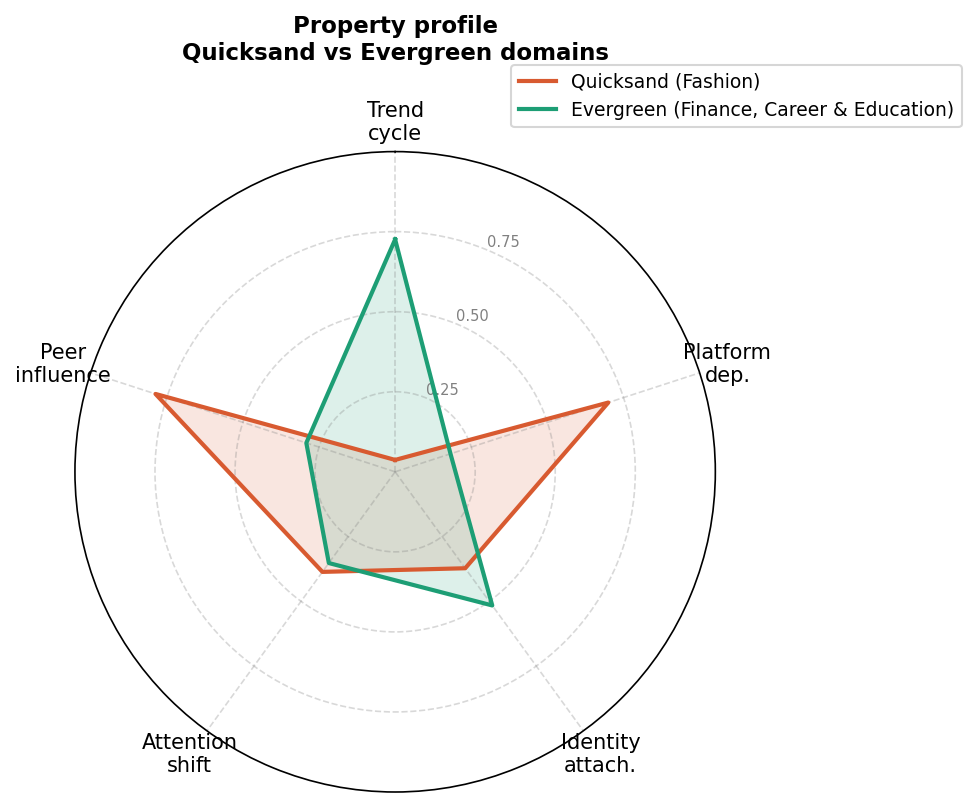

Chart 4 saved.


In [43]:
# ── CHART 4 — Radar: Quicksand vs Evergreen property profile ─────
# One insight: Quicksand domains high on peer+platform, 
#              Evergreen high on identity

import numpy as np

quicksand = d[d['tier'] == '🔴 Quicksand']['domain'].unique()
evergreen = d[d['tier'] == '🟢 Evergreen']['domain'].unique()

props  = ['trend_cycle_months','platform_dependency','identity_attachment',
          'attention_shift_rate','peer_influence_score']
labels = ['Trend\ncycle','Platform\ndep.','Identity\nattach.',
          'Attention\nshift','Peer\ninfluence']

def radar_avg(domains):
    sub  = d[d['domain'].isin(domains)]
    vals = sub[props].mean()
    return ((vals - d[props].min()) / (d[props].max() - d[props].min())).values.tolist()

q_vals = radar_avg(quicksand)
e_vals = radar_avg(evergreen)

N      = len(props)
angles = [n / float(N) * 2 * np.pi for n in range(N)] + [0]
q_vals += q_vals[:1]
e_vals += e_vals[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75])
ax.set_yticklabels(['0.25','0.50','0.75'], fontsize=7, color='gray')
ax.grid(color='gray', alpha=0.3)

ax.plot(angles, q_vals, color=ACCENT,       linewidth=2, label=f'Quicksand ({", ".join(quicksand)})')
ax.fill(angles, q_vals, color=ACCENT,       alpha=0.15)
ax.plot(angles, e_vals, color=ALPHA_COLOR,  linewidth=2, label=f'Evergreen ({", ".join(evergreen)})')
ax.fill(angles, e_vals, color=ALPHA_COLOR,  alpha=0.15)

ax.set_title('Property profile\nQuicksand vs Evergreen domains',
             fontsize=11, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.4, 1.15), fontsize=9)
plt.tight_layout()
plt.savefig('../outputs/charts/chart4_radar.png')
plt.show()
print("Chart 4 saved.")

### Chart 4 Insight — Radar

Quicksand (Fashion Gen Alpha) wins on:
→ Peer influence + Platform dependency
→ External pressure from all sides, no anchor

Evergreen (Finance, Career — Gen Alpha only) wins on:
→ Trend cycle length only
→ Everything else including identity is LOW

**Critical nuance — two types of Evergreen exist:**

Type 1 — True Evergreen: stable because identity-rooted
→ Mental Health Gen Z scores identity 9.0

Type 2 — False Evergreen: stable because not yet engaged  
→ Finance Gen Alpha scores identity 4.5
→ Career Gen Alpha scores identity 6.5

Finance and Career are Evergreen not because 
Alpha is deeply attached — but because Alpha 
hasn't encountered real financial or career 
pressure yet. It is indifference, not attachment,
that makes them stable.

When Alpha enters adulthood, these domains will 
shift from False Evergreen to active engagement —
likely jumping straight to Stable or Shifting tier.

## Conclusions

### The original question answered

We analysed 10 interest domains across Gen Z (1997–2012) 
and Gen Alpha (2013–2025) using a weighted volatility 
scoring engine built from 5 properties and 1 hard constraint.

---

### 1. Fashion is the only Quicksand domain — and only for Alpha

Every other domain has enough identity-attachment or 
trend-cycle length to avoid the Quicksand tier.
Fashion Gen Alpha scored 0.77 — the highest raw volatility 
in the entire dataset. Low identity attachment (5.5) + 
fast trend cycle + Shein/Temu removing cost barriers 
= no protection against churn.

---

### 2. Gen Z has zero Quicksand domains

Gen Z is mid-journey in every domain simultaneously.
They have started everything but finished nothing.
This is not stability — it is active engagement across 
all fronts at once. Everything needs attention now, 
but nothing is in freefall.

---

### 3. Mental Health is the single most universal domain

It ranks in the top 2 provider priority for BOTH cohorts.
Gen Z: 8.25. Gen Alpha: 9.50.
It is the only domain where Alpha scores higher than Gen Z
on provider priority AND it is Stable/Shifting for both.
Any product touching wellbeing has a guaranteed audience 
across generations.

---

### 4. The 3 factors framework held throughout

At dataset design we identified 3 volatility drivers:
- Self (identity) → protects against volatility
- Environment (platform, trends) → drives volatility  
- Conditions (peer, attention) → amplifies volatility

Every scoring result confirmed this framework.
Fast domains scored high on Environment + Conditions.
Slow domains scored high on Self/Identity.

---

### 5. Gen Alpha is paradoxically more volatile despite 
### stronger self-identity

Alpha cares MORE about self-image than Gen Z.
But their identity is aspirational not achieved —
built on what they want to be, not what they have lived.
When environment shifts, their identity shifts with it.
Stronger self-image + weaker identity foundation 
= higher volatility, not lower.

---

### Strategic summary for decision makers

| Cohort | Domain | Action |
|---|---|---|
| Gen Z | Sports & Fitness, Mental Health | Invest now — fastest growing |
| Gen Z | Finance, Career | Maintain — stable, identity-rooted |
| Gen Alpha | Mental Health, Activism | Act early — rapidly forming |
| Gen Alpha | Fashion | Constant refresh — only Quicksand domain |
| Both | Finance, Career (Alpha) | Low priority until Alpha matures |

---

### One line summary

**Sell to Gen Z today. Position for Gen Alpha tomorrow.**

---

### Limitations

1. Dataset is synthetic — values estimated from literature,
   not measured directly from populations
2. Gen Alpha data carries maturity bias — they are still 
   in early life stages, patterns based on early signals
3. India-specific dynamics not separately modelled —
   global sources used throughout
4. Domains analysed as monoliths — sub-domain variation
   exists within each (e.g. fitness vs traditional sports)